## 1. Import Libraries and Load Data

In [ ]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import IMBALANCED_DATASET, BALANCED_DATASET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Import custom models
from models.knn import KNN
from models.decision_tree import DecisionTree
from models.random_forest import RandomForest

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Helper Functions

We define helper functions to streamline the process of loading, preprocessing, training, and evaluating models across different datasets.

In [16]:
def load_and_preprocess(path):
    """
    Load dataset, drop non-numeric columns, and separate features/target.
    """
    df = pd.read_csv(path)
    print(f"Loaded dataset from {path} with shape {df.shape}")
    
    # Separate features and target
    X = df.drop(['longitude', 'latitude', 'class'], axis=1)
    y = df['class']
    
    # Drop non-numeric columns
    X = X.select_dtypes(include=[np.number])
    
    # Handle missing values
    if X.isnull().sum().sum() > 0:
        X = X.fillna(X.mean())
        
    return X, y, df

def evaluate_metrics(y_true, y_pred, model_name):
    """
    Calculate evaluation metrics.
    """
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred)
    }

def plot_results(results_df, y_test, predictions_dict, dataset_name):
    """
    Plot comparison metrics and confusion matrices.
    """
    # 1. Metrics Comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    results_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'Model Performance Comparison ({dataset_name})', fontsize=16, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 2. Confusion Matrices
    valid_preds = {k: v for k, v in predictions_dict.items() if v is not None}
    n_models = len(valid_preds)
    
    if n_models > 0:
        fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
        if n_models == 1: axes = [axes]
        
        for idx, (model_name, y_pred) in enumerate(valid_preds.items()):
            cm = confusion_matrix(y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                        xticklabels=['No Fire', 'Fire'],
                        yticklabels=['No Fire', 'Fire'])
            axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
            axes[idx].set_ylabel('True Label')
            axes[idx].set_xlabel('Predicted Label')
            
        plt.tight_layout()
        plt.show()

## 3. Experiment 1: Imbalanced Dataset

We test the models on the imbalanced dataset (70% Fire, 30% No Fire).
- **KNN & Decision Tree**: Trained on 80% train set, evaluated on 20% test set.
- **Random Forest**: Evaluated using Stratified 5-Fold Cross-Validation.

In [ ]:
# 1. Load and Preprocess
dataset_name = "Imbalanced Dataset"
X, y, df = load_and_preprocess(IMBALANCED_DATASET)

# 2. Split for KNN and DT (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = scaler.fit_transform(X) # For RF CV

results_imbalanced = []
predictions_imbalanced = {}

Loaded dataset from ../results/imbalanced_dataset.csv with shape (5462, 42)


In [9]:
# 3. KNN
print("\nTraining KNN...")
knn = KNN(k=7, distance_metric='euclidean')
knn.fit(X_train_scaled, y_train.values)
y_pred_knn = knn.predict(X_test_scaled)
results_imbalanced.append(evaluate_metrics(y_test, y_pred_knn, "KNN"))
predictions_imbalanced["KNN"] = y_pred_knn
print("KNN Training Completed.")


Training KNN...
KNN Training Completed.
KNN Training Completed.


In [11]:
# 4. Decision Tree
print("Training Decision Tree...")
dt = DecisionTree(max_depth=10, min_samples_split=5, min_samples_leaf=2)
dt.fit(X_train_scaled, y_train.values)
y_pred_dt = dt.predict(X_test_scaled)
results_imbalanced.append(evaluate_metrics(y_test, y_pred_dt, "Decision Tree"))
predictions_imbalanced["Decision Tree"] = y_pred_dt
print("Decision Tree Training Completed.")

Training Decision Tree...
Decision Tree Training Completed.
Decision Tree Training Completed.


In [ ]:
# 5. Random Forest (Stratified K-Fold)
print("Training Random Forest (Stratified K-Fold)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_metrics_list = []

fold = 1
for train_idx, val_idx in skf.split(X_scaled_full, y):
    print(f"  Processing Fold {fold}/5...")
    X_tr, X_val = X_scaled_full[train_idx], X_scaled_full[val_idx]
    y_tr, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values
    
    rf = RandomForest(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_tr, y_tr)
    y_pred_rf = rf.predict(X_val)
    
    rf_metrics_list.append(evaluate_metrics(y_val, y_pred_rf, f"RF_Fold_{fold}"))
    fold += 1
    
# Average RF metrics
rf_avg_metrics = pd.DataFrame(rf_metrics_list).mean(numeric_only=True).to_dict()
rf_avg_metrics['model'] = "Random Forest (CV Avg)"
results_imbalanced.append(rf_avg_metrics)
predictions_imbalanced["Random Forest"] = None # Placeholder

print("Random Forest Training Completed.")

Training Random Forest (Stratified K-Fold)...
  Processing Fold 1/5...



Results Summary (Imbalanced):
               accuracy  precision  recall  f1_score
model                                               
KNN            0.917658   0.894737     1.0  0.944444
KNN            0.924837   0.869318     1.0  0.930091
Decision Tree  1.000000   1.000000     1.0  1.000000


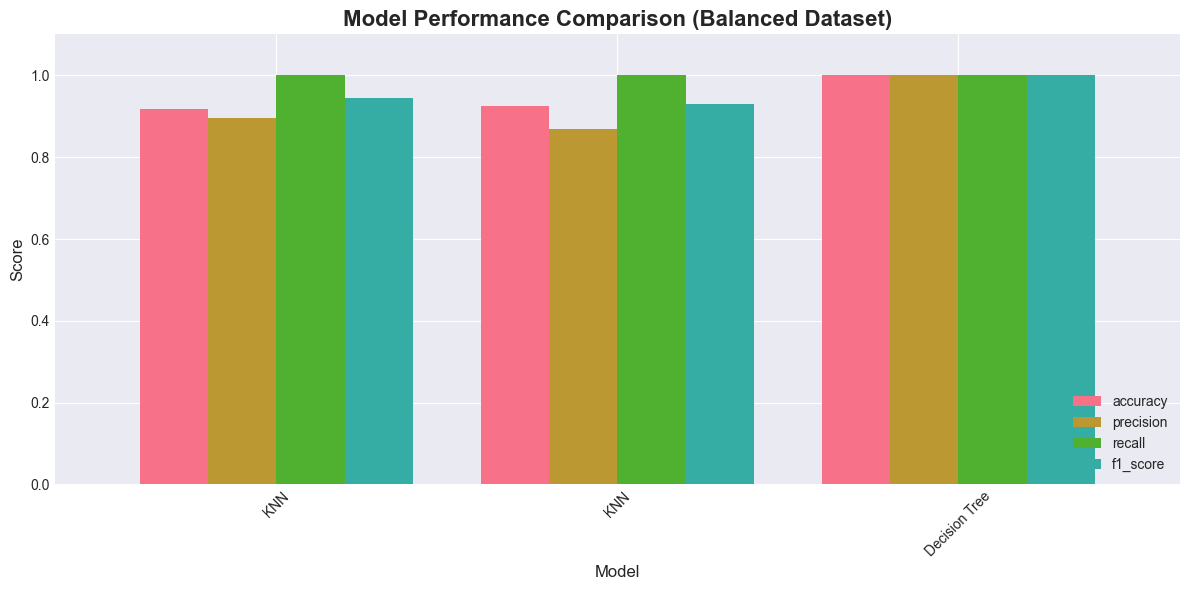

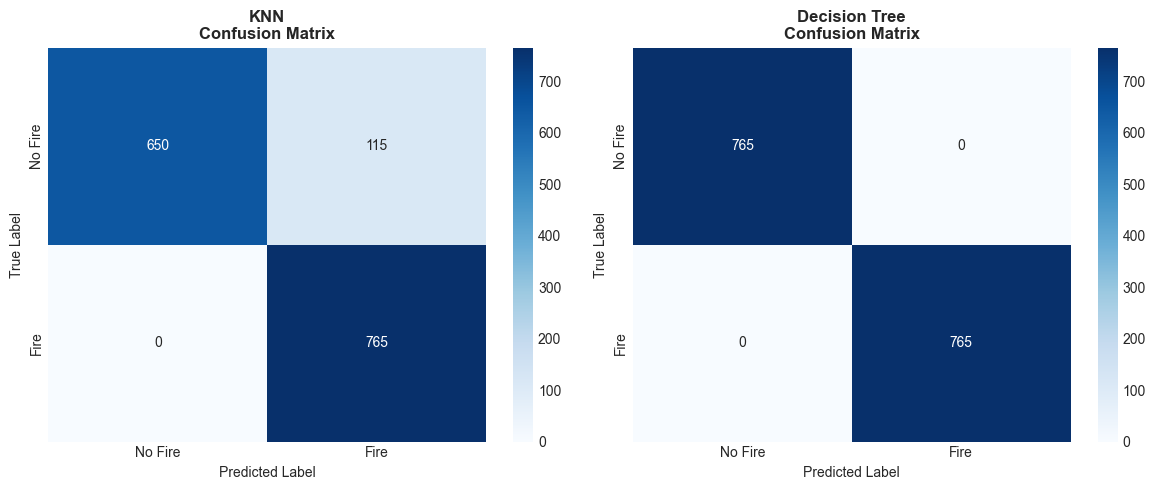

In [12]:
# 6. Results & Visualization
results_df_imbalanced = pd.DataFrame(results_imbalanced).set_index('model')
print("\nResults Summary (Imbalanced):")
print(results_df_imbalanced)

plot_results(results_df_imbalanced, y_test, predictions_imbalanced, dataset_name)

## 4. Experiment 2: Balanced Dataset

We test the models on the balanced dataset (50% Fire, 50% No Fire).
- **KNN & Decision Tree**: Trained on 80% train set, evaluated on 20% test set.
- **Random Forest**: Evaluated using Stratified 5-Fold Cross-Validation.

In [ ]:
# 1. Load and Preprocess
dataset_name = "Balanced Dataset"
X, y, df = load_and_preprocess(BALANCED_DATASET)

# 2. Split for KNN and DT (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = scaler.fit_transform(X) # For RF CV

results_balanced = []
predictions_balanced = {}

Loaded dataset from ../results/balanced_dataset.csv with shape (7648, 42)


In [8]:
# 3. KNN
print("\nTraining KNN...")
knn = KNN(k=5, distance_metric='euclidean')
knn.fit(X_train_scaled, y_train.values)
y_pred_knn = knn.predict(X_test_scaled)
results_balanced.append(evaluate_metrics(y_test, y_pred_knn, "KNN"))
predictions_balanced["KNN"] = y_pred_knn
print("KNN Training Completed.")


Training KNN...
KNN Training Completed.
KNN Training Completed.


In [13]:
# 4. Decision Tree
print("Training Decision Tree...")
dt = DecisionTree(max_depth=10, min_samples_split=5, min_samples_leaf=2)
dt.fit(X_train_scaled, y_train.values)
y_pred_dt = dt.predict(X_test_scaled)
results_balanced.append(evaluate_metrics(y_test, y_pred_dt, "Decision Tree"))
predictions_balanced["Decision Tree"] = y_pred_dt
print("Decision Tree Training Completed.")

Training Decision Tree...
Decision Tree Training Completed.
Decision Tree Training Completed.


In [ ]:
# 5. Random Forest (Stratified K-Fold)
print("Training Random Forest (Stratified K-Fold)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_metrics_list = []

fold = 1
for train_idx, val_idx in skf.split(X_scaled_full, y):
    print(f"  Processing Fold {fold}/5...")
    X_tr, X_val = X_scaled_full[train_idx], X_scaled_full[val_idx]
    y_tr, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values
    
    rf = RandomForest(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_tr, y_tr)
    y_pred_rf = rf.predict(X_val)
    
    rf_metrics_list.append(evaluate_metrics(y_val, y_pred_rf, f"RF_Fold_{fold}"))
    fold += 1
    
# Average RF metrics
rf_avg_metrics = pd.DataFrame(rf_metrics_list).mean(numeric_only=True).to_dict()
rf_avg_metrics['model'] = "Random Forest (CV Avg)"
results_balanced.append(rf_avg_metrics)
predictions_balanced["Random Forest"] = None # Placeholder

print("Random Forest Training Completed.")


Results Summary (Balanced):
               accuracy  precision  recall  f1_score
model                                               
KNN            0.946405   0.903188     1.0  0.949132
Decision Tree  1.000000   1.000000     1.0  1.000000


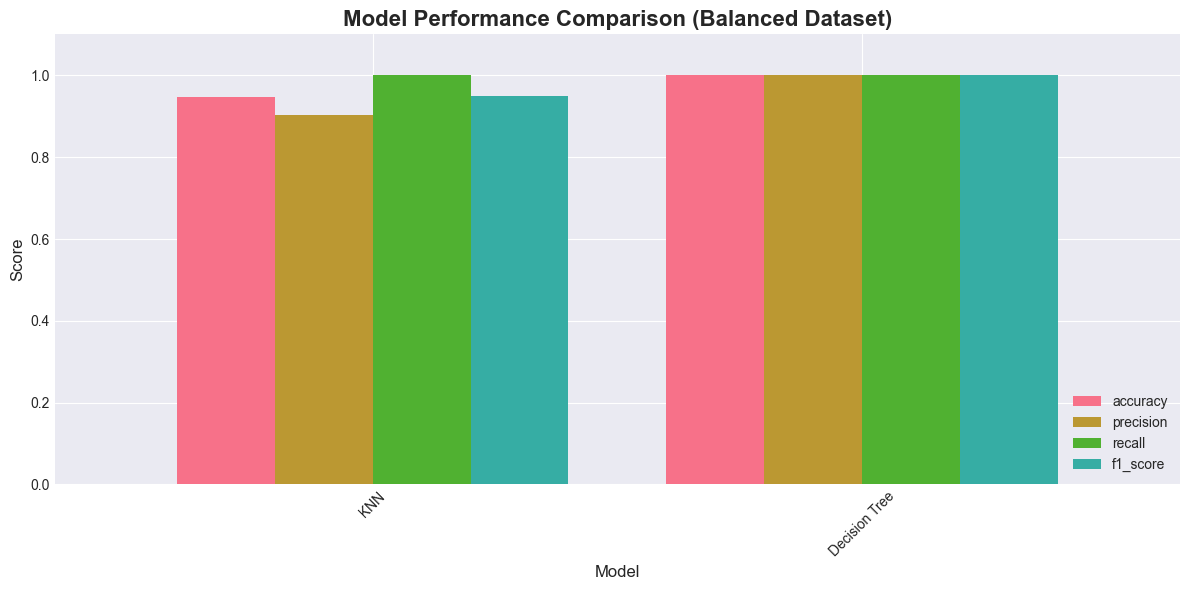

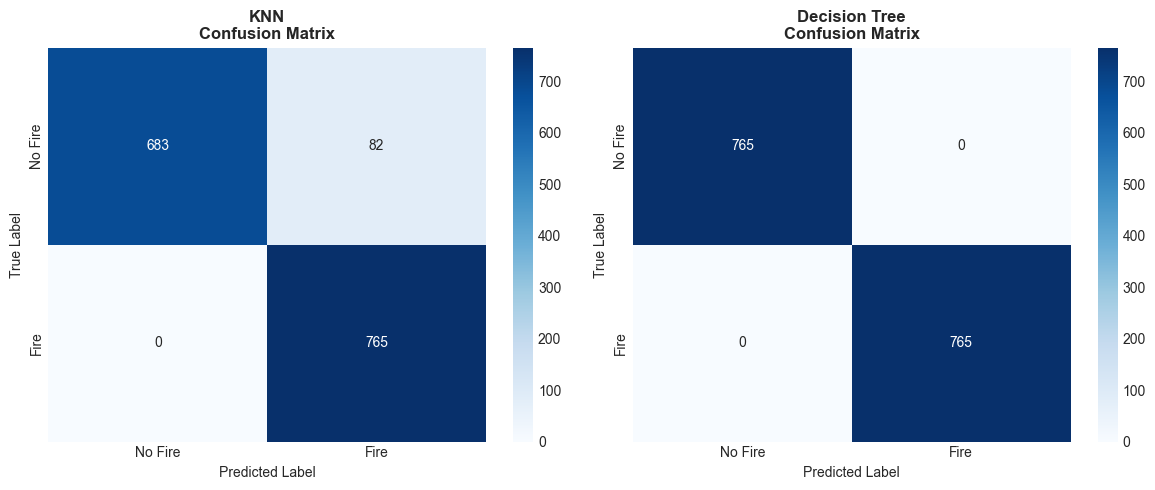

In [14]:
# 6. Results & Visualization
results_df_balanced = pd.DataFrame(results_balanced).set_index('model')
print("\nResults Summary (Balanced):")
print(results_df_balanced)

plot_results(results_df_balanced, y_test, predictions_balanced, dataset_name)